# 1. Introduction

Casting is an important manufacturing process used to produce different industrial components.

Defects in castings can affect the quality, strength and reliability of the final product. Manual inspection can be time-consuming and may be affected by human error.

In this project, a Convolutional Neural Network (CNN) is developed to automatically classify casting images as:

- OK casting
- Defective casting

This is a binary image classification problem.

### Input
Casting image

### Output
- 0 → OK
- 1 → Defective

In [2]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Python executable: c:\Users\S_Gayathri\AppData\Local\Programs\Python\Python312\python.exe


In [3]:
%pip install numpy pandas matplotlib seaborn pillow scikit-learn tensorflow

  Using cached numpy-2.5.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.5-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.0-cp312-cp312-win_amd64.whl.metadata (6

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import sklearn
import tensorflow as tf

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)
print("All libraries imported successfully!")

NumPy: 2.5.2
Pandas: 3.0.5
TensorFlow: 2.21.0
All libraries imported successfully!


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow Version:", tf.__version__)
print(
    "Num GPUs Available:",
    len(tf.config.list_physical_devices("GPU"))
)

TensorFlow Version: 2.21.0
Num GPUs Available: 0


# 3. Dataset Description

The dataset contains casting images divided into training and testing sets.

The dataset follows this structure:

casting_data/
├── train/
│   ├── ok_front/
│   └── def_front/
└── test/
    ├── ok_front/
    └── def_front/

### Classes

| Folder | Meaning | Label |
|---|---|---|
| `ok_front` | Non-defective casting | 0 |
| `def_front` | Defective casting | 1 |

The training dataset is used to train the CNN model, while the test dataset is used to evaluate the model on unseen images.

In [3]:
# 4. Load Dataset

DATA_DIR = Path("casting_data")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATA_DIR.resolve()}"
    )

if not TRAIN_DIR.exists():
    raise FileNotFoundError(
        f"Training folder not found: {TRAIN_DIR.resolve()}"
    )

if not TEST_DIR.exists():
    raise FileNotFoundError(
        f"Testing folder not found: {TEST_DIR.resolve()}"
    )

print("Dataset path:", DATA_DIR.resolve())
print("Training path:", TRAIN_DIR.resolve())
print("Testing path:", TEST_DIR.resolve())

print("\nTraining Classes:")
print([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])

print("\nTesting Classes:")
print([p.name for p in TEST_DIR.iterdir() if p.is_dir()])

Dataset path: C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 13 - Building an Image Recognition System for Quality Control\S.Gayathri -G40 AIML\casting_data
Training path: C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 13 - Building an Image Recognition System for Quality Control\S.Gayathri -G40 AIML\casting_data\train
Testing path: C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 13 - Building an Image Recognition System for Quality Control\S.Gayathri -G40 AIML\casting_data\test

Training Classes:
['def_front', 'ok_front']

Testing Classes:
['def_front', 'ok_front']


In [4]:
# Count images in each class

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"
}

def count_images(folder):
    counts = {}

    for class_dir in sorted(folder.iterdir()):
        if class_dir.is_dir():
            counts[class_dir.name] = sum(
                1
                for p in class_dir.rglob("*")
                if p.is_file()
                and p.suffix.lower() in IMAGE_EXTENSIONS
            )

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training image counts:")
print(train_counts)

print("\nTesting image counts:")
print(test_counts)

classes = sorted(
    set(train_counts.keys()) | set(test_counts.keys())
)

count_df = pd.DataFrame({
    "Class": classes,
    "Train": [train_counts.get(c, 0) for c in classes],
    "Test": [test_counts.get(c, 0) for c in classes]
})

display(count_df)

Training image counts:
{'def_front': 3758, 'ok_front': 2875}

Testing image counts:
{'def_front': 453, 'ok_front': 262}


,Class,Train,Test
0,def_front,3758,453
1,ok_front,2875,262


# 5. Explore Dataset

Dataset exploration is performed to understand:

- Number of images in each class
- Image dimensions
- Class distribution
- Dataset quality
- Sample images

In [5]:
# Explore image dimensions

def inspect_image_sizes(folder, max_images=500):

    sizes = []

    for class_dir in sorted(folder.iterdir()):

        if not class_dir.is_dir():
            continue

        for image_path in class_dir.rglob("*"):

            if (
                image_path.is_file()
                and image_path.suffix.lower() in IMAGE_EXTENSIONS
            ):

                try:
                    with Image.open(image_path) as img:
                        sizes.append(img.size)

                except Exception:
                    pass

                if len(sizes) >= max_images:
                    break

        if len(sizes) >= max_images:
            break

    return sizes


sizes = inspect_image_sizes(TRAIN_DIR)

if len(sizes) > 0:

    size_df = pd.DataFrame(
        sizes,
        columns=["Width", "Height"]
    )

    print("Image dimension statistics:")
    display(size_df.describe())

    print("\nMost common image sizes:")
    display(size_df.value_counts().head(10))

else:

    print("No readable images found.")

Image dimension statistics:


,Width,Height
count,500.0,500.0
mean,300.0,300.0
std,0.0,0.0
min,300.0,300.0
25%,300.0,300.0
50%,300.0,300.0
75%,300.0,300.0
max,300.0,300.0



Most common image sizes:


Width  Height
300    300       500
Name: count, dtype: int64

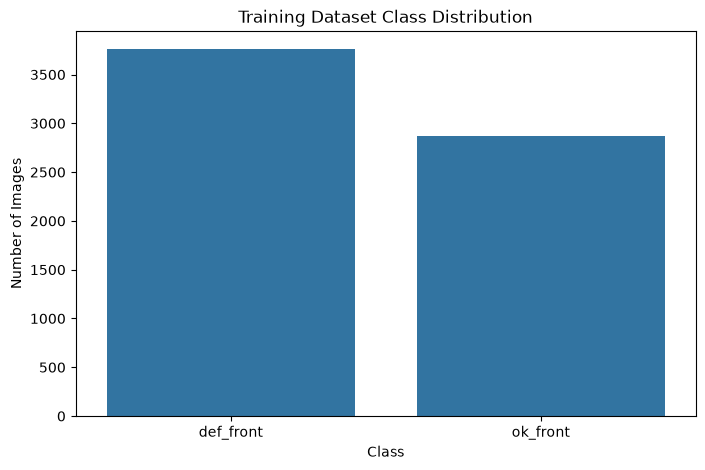

In [6]:
# Visualize class distribution

plt.figure(figsize=(8, 5))

sns.barplot(
    data=count_df,
    x="Class",
    y="Train"
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# 6. Display Sample Images

Sample images from both classes are displayed to understand the visual differences between:

- OK castings
- Defective castings

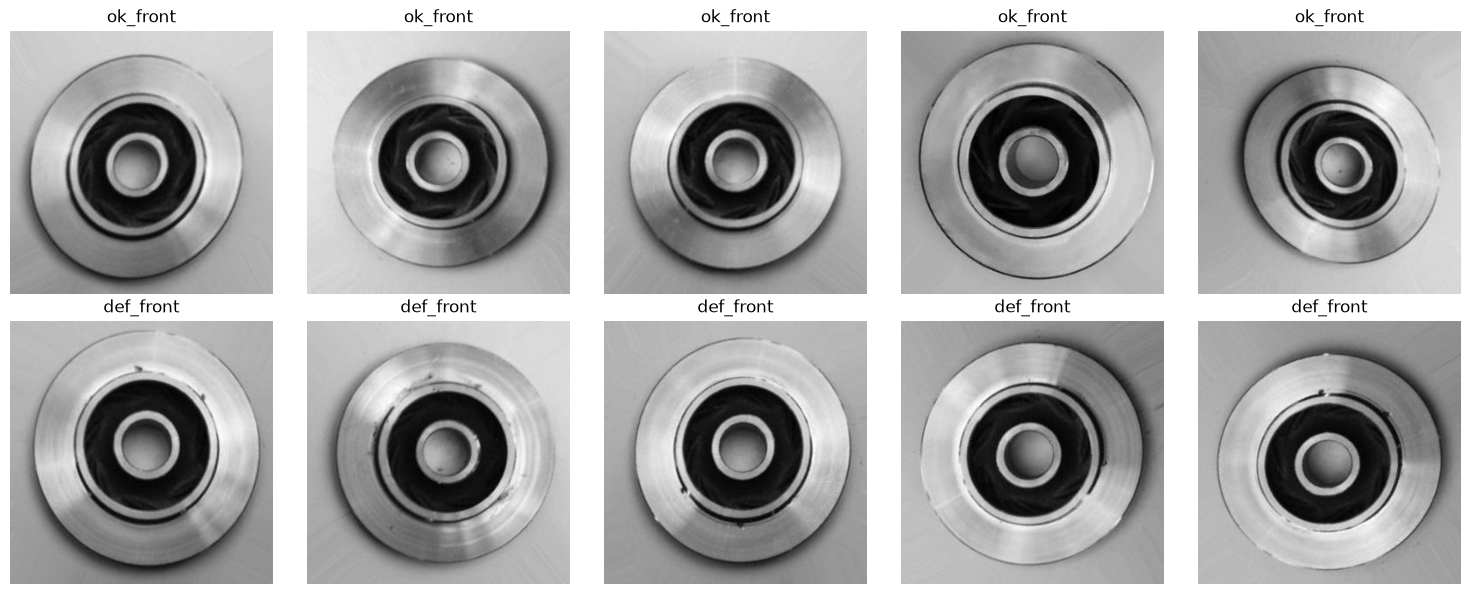

In [7]:
# Display sample images

CLASS_NAMES = ["ok_front", "def_front"]


def get_image_paths(folder, class_name, n=5):

    class_dir = folder / class_name

    paths = [
        p
        for p in class_dir.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    random.shuffle(paths)

    return paths[:n]


fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

for row, class_name in enumerate(CLASS_NAMES):

    sample_paths = get_image_paths(
        TRAIN_DIR,
        class_name,
        n=5
    )

    for col in range(5):

        ax = axes[row, col]
        ax.axis("off")

        if col < len(sample_paths):

            img = Image.open(
                sample_paths[col]
            ).convert("RGB")

            ax.imshow(img)

            ax.set_title(class_name)

plt.tight_layout()
plt.show()

# 7. Data Preparation

Before feeding images into the CNN:

1. Images are resized to a fixed size.
2. Pixel values are normalized from 0–255 to 0–1.
3. Training data is shuffled.
4. Validation data is created from the training dataset.
5. Test data is kept separate for final evaluation.

### Image Size

128 × 128 pixels

### Batch Size

32 images per batch

### Validation Split

20% of the training data

In [8]:
# Set parameters

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE = 32

VALIDATION_SPLIT = 0.20

print("Image Height:", IMG_HEIGHT)
print("Image Width:", IMG_WIDTH)
print("Batch Size:", BATCH_SIZE)
print("Validation Split:", VALIDATION_SPLIT)

Image Height: 128
Image Width: 128
Batch Size: 32
Validation Split: 0.2


In [9]:
# Load Training Dataset

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,

    labels="inferred",

    label_mode="binary",

    image_size=(
        IMG_HEIGHT,
        IMG_WIDTH
    ),

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED,

    validation_split=VALIDATION_SPLIT,

    subset="training",

    class_names=CLASS_NAMES
)


# Load Validation Dataset

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,

    labels="inferred",

    label_mode="binary",

    image_size=(
        IMG_HEIGHT,
        IMG_WIDTH
    ),

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED,

    validation_split=VALIDATION_SPLIT,

    subset="validation",

    class_names=CLASS_NAMES
)


# Load Test Dataset

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,

    labels="inferred",

    label_mode="binary",

    image_size=(
        IMG_HEIGHT,
        IMG_WIDTH
    ),

    batch_size=BATCH_SIZE,

    shuffle=False,

    class_names=CLASS_NAMES
)


print("\nClass Mapping:")

for i, name in enumerate(CLASS_NAMES):
    print(i, "=", name)

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.

Class Mapping:
0 = ok_front
1 = def_front


In [10]:
# Optimize dataset pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

print("Dataset pipeline optimized successfully.")

Dataset pipeline optimized successfully.


# 8. Data Augmentation

Data augmentation generates slightly modified versions of training images.

This helps the model:

- Learn different variations of images
- Reduce overfitting
- Improve generalization
- Become more robust to small image changes

The following transformations are used:

- Random horizontal flip
- Random rotation
- Random zoom
- Random translation

In [11]:
# Data Augmentation

data_augmentation = keras.Sequential(

    [

        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.05
        ),

        layers.RandomZoom(
            0.10
        ),

        layers.RandomTranslation(
            0.05,
            0.05
        )

    ],

    name="data_augmentation"
)


print("Data augmentation created successfully.")

Data augmentation created successfully.


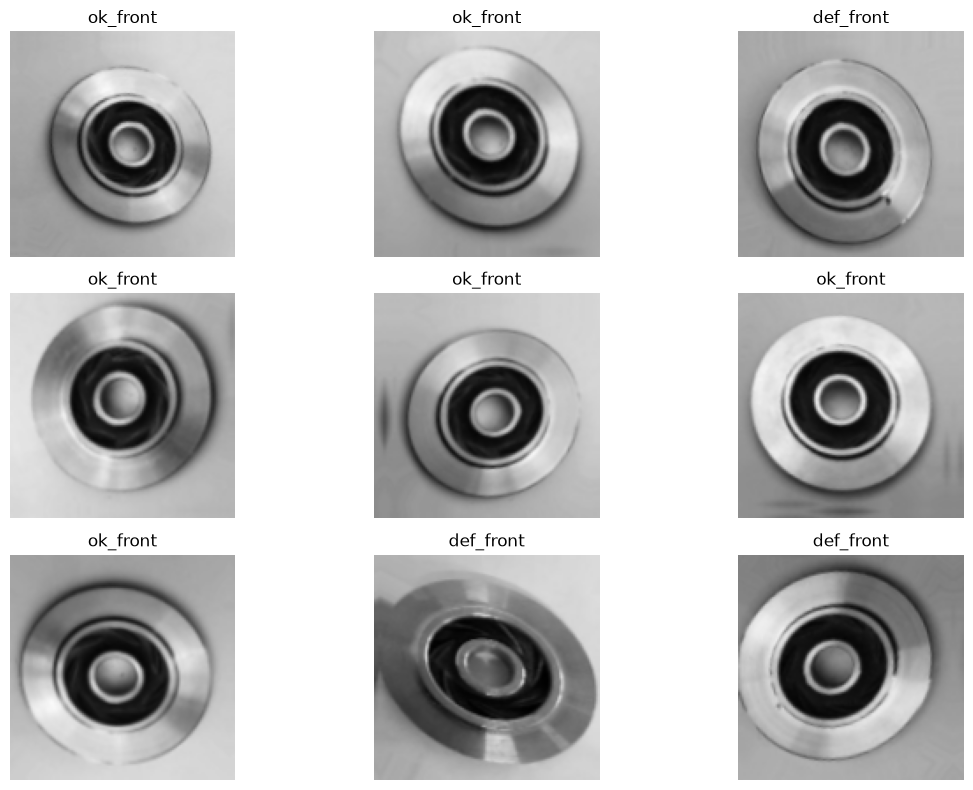

In [12]:
# Display augmented images

sample_images, sample_labels = next(
    iter(train_ds)
)

plt.figure(figsize=(12, 8))

for i in range(
    min(9, len(sample_images))
):

    augmented_image = data_augmentation(
        tf.expand_dims(
            sample_images[i],
            0
        ),
        training=True
    )

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        augmented_image[0].numpy().astype(
            "uint8"
        )
    )

    label = int(
        sample_labels[i].numpy()[0]
    )

    plt.title(
        CLASS_NAMES[label]
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

# 9. CNN Architecture

The Convolutional Neural Network contains:

1. Input Layer
2. Data Augmentation
3. Rescaling Layer
4. Convolutional Layer
5. Max Pooling Layer
6. Convolutional Layer
7. Max Pooling Layer
8. Convolutional Layer
9. Max Pooling Layer
10. Convolutional Layer
11. Max Pooling Layer
12. Dropout
13. Flatten
14. Dense Layer
15. Dropout
16. Sigmoid Output Layer

The final sigmoid layer produces the probability that the casting image is defective.

In [13]:
# 9. CNN Architecture

model = keras.Sequential([

    layers.Input(
        shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            3
        )
    ),

    # Data augmentation
    data_augmentation,

    # Normalize pixels
    layers.Rescaling(
        1.0 / 255
    ),

    # CNN Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # CNN Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # CNN Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # CNN Block 4
    layers.Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Regularization
    layers.Dropout(
        0.30
    ),

    # Convert feature maps to vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(
        0.40
    ),

    # Binary classification
    layers.Dense(
        1,
        activation="sigmoid"
    )

])


print("CNN model created successfully.")

CNN model created successfully.


# 10. Model Summary

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,485,825 (9.48 MB)

 Trainable params: 2,485,825 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

# 11. Model Compilation

Since this is a binary classification problem, the model uses:

### Loss Function
`Binary Cross Entropy`

### Optimizer
`Adam`

### Metrics
- Accuracy
- Precision
- Recall

In [15]:
# Model Compilation

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        )

    ]
)


print("Model compiled successfully.")

Model compiled successfully.


# 12. Model Training

The CNN is trained using the training dataset.

### Callbacks

**EarlyStopping**
- Stops training when validation loss stops improving.

**ReduceLROnPlateau**
- Reduces learning rate when the model stops improving.

**ModelCheckpoint**
- Saves the best performing model.

In [16]:
# Model Training

MODEL_PATH = "best_casting_cnn.keras"


callbacks = [

    keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True,

        verbose=1
    ),


    keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=2,

        min_lr=1e-6,

        verbose=1
    ),


    keras.callbacks.ModelCheckpoint(

        MODEL_PATH,

        monitor="val_loss",

        save_best_only=True,

        verbose=1
    )

]


EPOCHS = 20


history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks

)

Epoch 1/20


c:\Users\S_Gayathri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 918ms/step - accuracy: 0.6213 - loss: 0.6466 - precision: 0.6150 - recall: 0.8679
Epoch 1: val_loss improved from None to 0.51212, saving model to best_casting_cnn.keras

Epoch 1: finished saving model to best_casting_cnn.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.6213 - loss: 0.6466 - precision: 0.6150 - recall: 0.8679 - val_accuracy: 0.7338 - val_loss: 0.5121 - val_precision: 0.7334 - val_recall: 0.8619 - learning_rate: 0.0010
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.7469 - loss: 0.5115 - precision: 0.7671 - recall: 0.7880
Epoch 2: val_loss improved from 0.51212 to 0.36368, saving model to best_casting_cnn.keras

Epoch 2: finished saving model to best_casting_cnn.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 120s 725ms/step - accuracy: 0.7469 - loss: 0.5115 - precision: 0.7671 - recall: 0.7880 - val_accuracy: 0.8499 - val_loss: 0.3637 - val_precision: 0.8923 - val_recall: 0.8478 - learning_rate: 0.0010
Epoch 3/20
166/

# 13. Training Accuracy / Loss

Training and validation accuracy/loss are plotted to understand model performance.

### Accuracy

Higher accuracy indicates better classification performance.

### Loss

Lower loss indicates that the model predictions are closer to the actual labels.

,accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall,learning_rate
15,0.990390,0.036862,0.994589,0.988239,0.951735,0.161886,0.998611,0.919437,0.000125
16,0.987564,0.046825,0.993890,0.983871,0.945701,0.172843,0.987637,0.919437,0.000125
17,0.988129,0.040024,0.995240,0.983535,0.941931,0.186756,0.963206,0.937340,0.000125
18,0.993405,0.031129,0.995953,0.992271,0.944947,0.216066,0.998594,0.907928,0.000063
19,0.993405,0.031691,0.997295,0.990927,0.949472,0.182581,0.995839,0.918159,0.000063


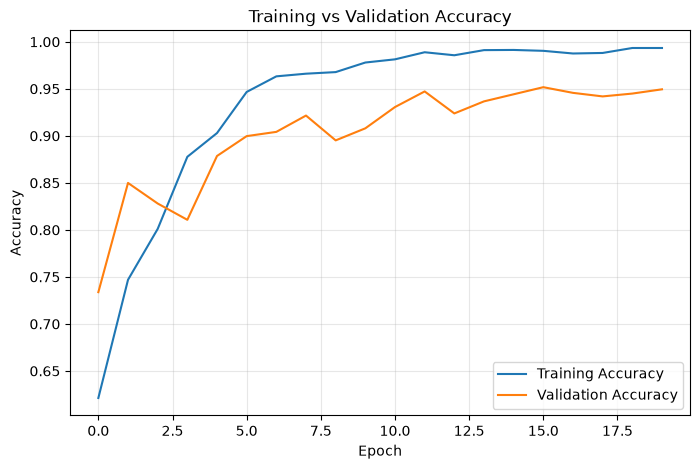

In [17]:
# Training History

history_df = pd.DataFrame(
    history.history
)

display(
    history_df.tail()
)


# Plot Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training vs Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

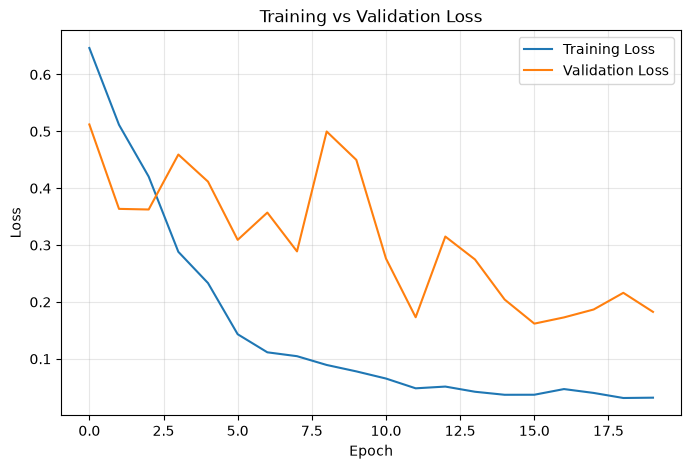

In [18]:
# Plot Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training vs Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# 14. Model Evaluation

The trained model is evaluated on the unseen test dataset.

The following metrics are calculated:

- Test Loss
- Test Accuracy
- Test Precision
- Test Recall

In [19]:
# Model Evaluation

test_results = model.evaluate(
    test_ds,
    verbose=1
)

print("\nTest Results:")

for metric_name, value in zip(
    model.metrics_names,
    test_results
):

    print(
        f"{metric_name}: {value:.4f}"
    )

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - accuracy: 0.9524 - loss: 0.1459 - precision: 0.9883 - recall: 0.9360

Test Results:
loss: 0.1459
compile_metrics: 0.9524


# 15. Classification Report

The classification report provides:

- Precision
- Recall
- F1-score
- Support

The report is generated for:

- `ok_front`
- `def_front`

In [20]:
# Generate predictions

y_true = np.concatenate(
    [
        labels.numpy().ravel()
        for _, labels in test_ds
    ]
).astype(int)


y_prob = model.predict(
    test_ds,
    verbose=1
).ravel()


DEFAULT_THRESHOLD = 0.50


y_pred = (
    y_prob >= DEFAULT_THRESHOLD
).astype(int)


print(
    "Number of Test Images:",
    len(y_true)
)

print(
    "Number of Predictions:",
    len(y_pred)
)


# Classification Report

print("\nClassification Report:\n")

print(
    classification_report(

        y_true,

        y_pred,

        labels=[0, 1],

        target_names=CLASS_NAMES,

        digits=4,

        zero_division=0

    )
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step
Number of Test Images: 715
Number of Predictions: 715

Classification Report:

              precision    recall  f1-score   support

    ok_front     0.8986    0.9809    0.9380       262
   def_front     0.9883    0.9360    0.9615       453

    accuracy                         0.9524       715
   macro avg     0.9435    0.9584    0.9497       715
weighted avg     0.9555    0.9524    0.9528       715



# 16. Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions.

### True Negative (TN)
OK image correctly classified as OK.

### True Positive (TP)
Defective image correctly classified as defective.

### False Positive (FP)
OK image incorrectly classified as defective.

### False Negative (FN)
Defective image incorrectly classified as OK.

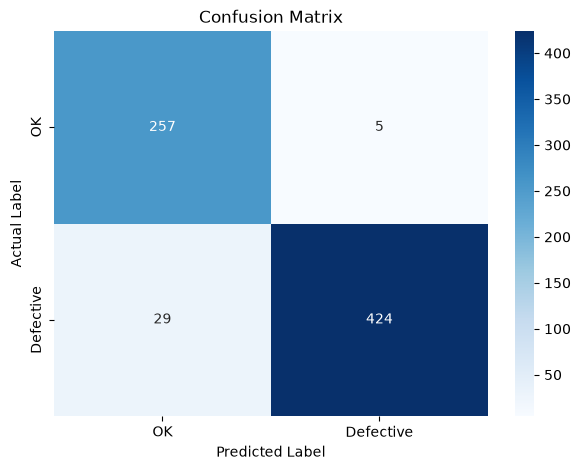

True Negative : 257
False Positive: 5
False Negative: 29
True Positive : 424


In [21]:
# Confusion Matrix

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)


plt.figure(
    figsize=(7, 5)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "OK",
        "Defective"
    ],

    yticklabels=[
        "OK",
        "Defective"
    ]

)


plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    "Confusion Matrix"
)

plt.show()


tn, fp, fn, tp = cm.ravel()


print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

# 17. False Positive / False Negative Analysis

### False Positive

An actual `ok_front` image is predicted as `def_front`.

This means the model incorrectly identifies a good casting as defective.

### False Negative

An actual `def_front` image is predicted as `ok_front`.

This is particularly important in industrial quality inspection because a defective component may be accepted as a good component.

Therefore, false negatives should be carefully analyzed.

In [22]:
# Collect test image paths

test_image_paths = []


for class_name in CLASS_NAMES:

    class_dir = TEST_DIR / class_name

    paths = sorted(

        [

            p

            for p in class_dir.rglob("*")

            if (

                p.is_file()

                and

                p.suffix.lower()
                in IMAGE_EXTENSIONS

            )

        ]

    )

    test_image_paths.extend(paths)


print(
    "Collected image paths:",
    len(test_image_paths)
)

print(
    "Model test labels:",
    len(y_true)
)

Collected image paths: 715
Model test labels: 715


In [23]:
# Create prediction results DataFrame

results_df = pd.DataFrame({

    "path":
        [
            str(p)
            for p in test_image_paths
        ][:len(y_true)],

    "actual":
        y_true[:len(test_image_paths)],

    "prob_defective":
        y_prob[:len(test_image_paths)],

    "predicted":
        y_pred[:len(test_image_paths)]

})


results_df["actual_name"] = (
    results_df["actual"]
    .map({
        0: "ok_front",
        1: "def_front"
    })
)


results_df["predicted_name"] = (
    results_df["predicted"]
    .map({
        0: "ok_front",
        1: "def_front"
    })
)


results_df["result"] = np.where(

    results_df["actual"]
    ==
    results_df["predicted"],

    "Correct",

    "Incorrect"

)


display(
    results_df.head()
)

,path,actual,prob_defective,predicted,actual_name,predicted_name,result
0,casting_data\test\ok_front\cast_ok_0_10.jpeg,0,0.000690,0,ok_front,ok_front,Correct
1,casting_data\test\ok_front\cast_ok_0_1001.jpeg,0,0.000686,0,ok_front,ok_front,Correct
2,casting_data\test\ok_front\cast_ok_0_1002.jpeg,0,0.000161,0,ok_front,ok_front,Correct
3,casting_data\test\ok_front\cast_ok_0_1003.jpeg,0,0.018228,0,ok_front,ok_front,Correct
4,casting_data\test\ok_front\cast_ok_0_1019.jpeg,0,0.001051,0,ok_front,ok_front,Correct


Number of False Positives: 5


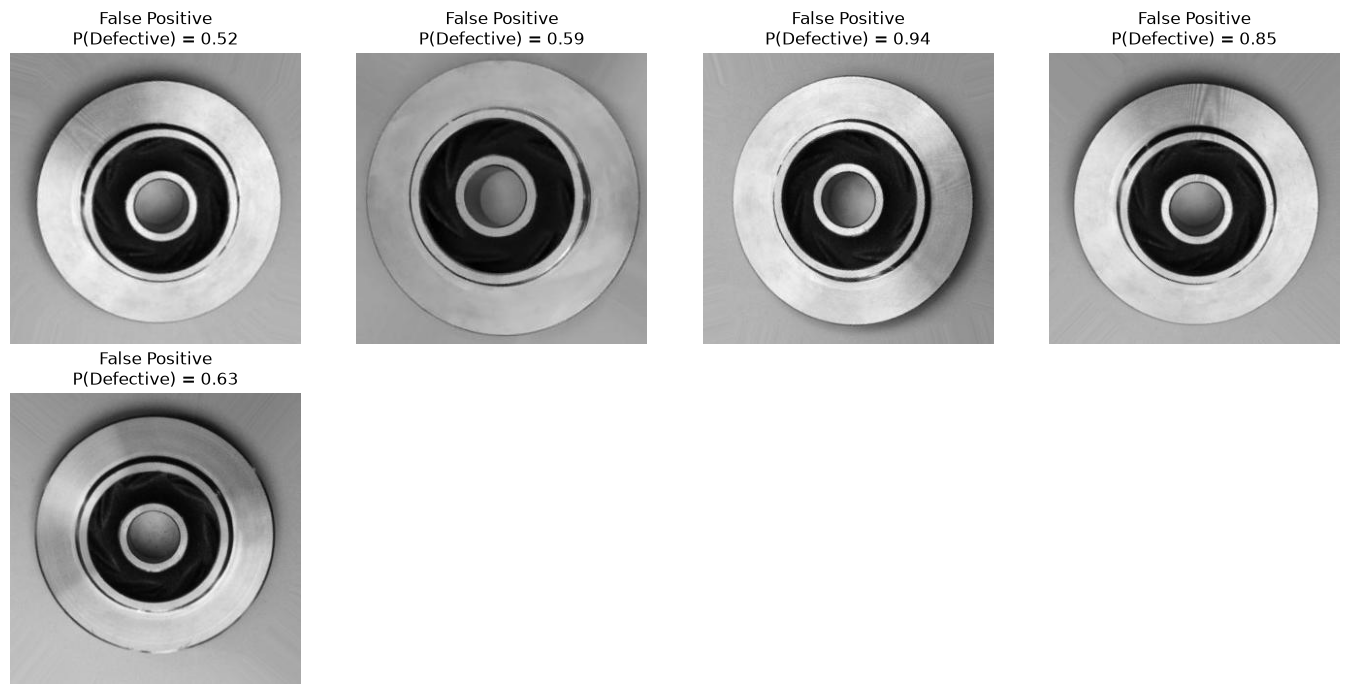

In [24]:
# False Positive Analysis

false_positives = results_df[

    (results_df["actual"] == 0)

    &

    (results_df["predicted"] == 1)

]


print(
    "Number of False Positives:",
    len(false_positives)
)


if len(false_positives) > 0:

    n_show = min(
        8,
        len(false_positives)
    )


    fig, axes = plt.subplots(
        2,
        4,
        figsize=(14, 7)
    )


    axes = axes.ravel()


    for i in range(8):
        axes[i].axis("off")


    for i, (_, row) in enumerate(
        false_positives
        .head(n_show)
        .iterrows()
    ):

        img = Image.open(
            row["path"]
        ).convert("RGB")


        axes[i].imshow(img)


        axes[i].set_title(

            f"False Positive\n"
            f"P(Defective) = "
            f"{row['prob_defective']:.2f}"

        )


        axes[i].axis("off")


    plt.tight_layout()

    plt.show()

else:

    print(
        "No false positives found."
    )

Number of False Negatives: 29


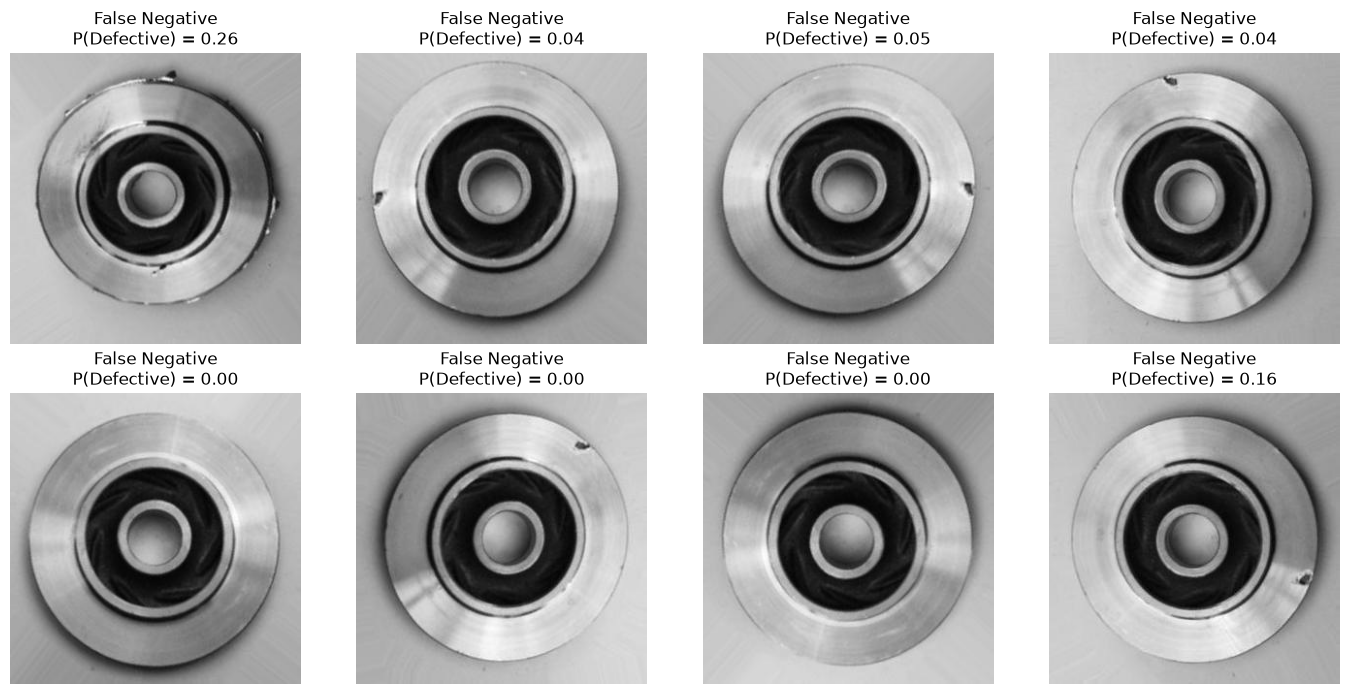

In [25]:
# False Negative Analysis

false_negatives = results_df[

    (results_df["actual"] == 1)

    &

    (results_df["predicted"] == 0)

]


print(
    "Number of False Negatives:",
    len(false_negatives)
)


if len(false_negatives) > 0:

    n_show = min(
        8,
        len(false_negatives)
    )


    fig, axes = plt.subplots(
        2,
        4,
        figsize=(14, 7)
    )


    axes = axes.ravel()


    for i in range(8):
        axes[i].axis("off")


    for i, (_, row) in enumerate(
        false_negatives
        .head(n_show)
        .iterrows()
    ):

        img = Image.open(
            row["path"]
        ).convert("RGB")


        axes[i].imshow(img)


        axes[i].set_title(

            f"False Negative\n"
            f"P(Defective) = "
            f"{row['prob_defective']:.2f}"

        )


        axes[i].axis("off")


    plt.tight_layout()

    plt.show()

else:

    print(
        "No false negatives found."
    )

# 18. Threshold Comparison

The CNN produces a probability between 0 and 1.

For example:

- Threshold = 0.50
  - Probability ≥ 0.50 → Defective
  - Probability < 0.50 → OK

Changing the threshold affects:

- Accuracy
- Precision
- Recall
- F1-score
- False Positives
- False Negatives

For industrial defect detection, a lower threshold may help detect more defects, but it can also increase false positives.

In [26]:
# Compare Classification Thresholds

thresholds = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]


threshold_rows = []


for threshold in thresholds:

    predictions = (
        y_prob >= threshold
    ).astype(int)


    tn_t, fp_t, fn_t, tp_t = (
        confusion_matrix(
            y_true,
            predictions,
            labels=[0, 1]
        ).ravel()
    )


    threshold_rows.append({

        "Threshold": threshold,

        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "F1 Score":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "False Positives":
            fp_t,

        "False Negatives":
            fn_t,

        "True Positives":
            tp_t,

        "True Negatives":
            tn_t

    })


threshold_df = pd.DataFrame(
    threshold_rows
)


display(
    threshold_df
)

,Threshold,Accuracy,Precision,Recall,F1 Score,False Positives,False Negatives,True Positives,True Negatives
0,0.2,0.955245,0.977324,0.951435,0.964206,10,22,431,252
1,0.3,0.953846,0.979452,0.947020,0.962963,9,24,429,253
2,0.4,0.953846,0.986111,0.940397,0.962712,6,27,426,256
3,0.5,0.952448,0.988345,0.935982,0.961451,5,29,424,257
4,0.6,0.945455,0.992857,0.920530,0.955326,3,36,417,259
5,0.7,0.942657,0.995192,0.913907,0.952819,2,39,414,260
6,0.8,0.934266,0.995122,0.900662,0.945539,2,45,408,260


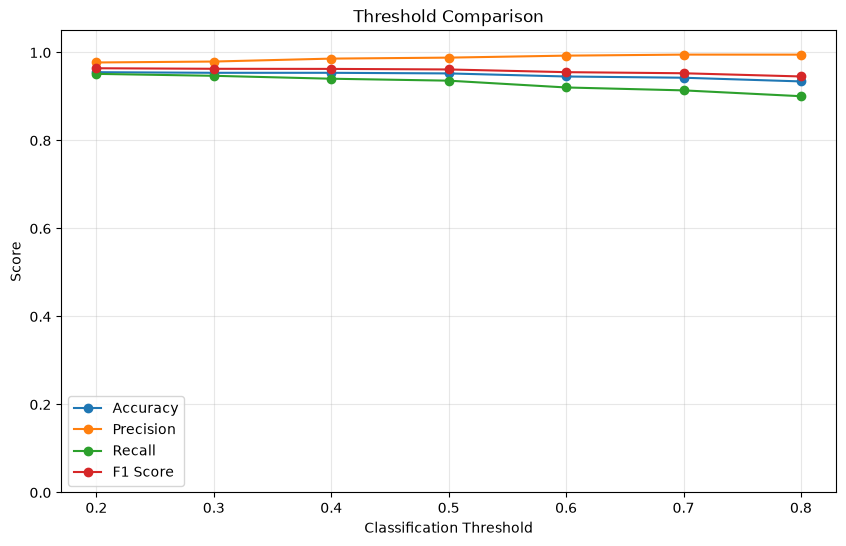

In [27]:
# Plot threshold comparison

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    threshold_df["Threshold"],

    threshold_df["Accuracy"],

    marker="o",

    label="Accuracy"

)


plt.plot(

    threshold_df["Threshold"],

    threshold_df["Precision"],

    marker="o",

    label="Precision"

)


plt.plot(

    threshold_df["Threshold"],

    threshold_df["Recall"],

    marker="o",

    label="Recall"

)


plt.plot(

    threshold_df["Threshold"],

    threshold_df["F1 Score"],

    marker="o",

    label="F1 Score"

)


plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Threshold Comparison"
)

plt.xticks(
    thresholds
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

# 19. New Image Prediction

The trained CNN can also classify a new casting image.

The prediction process is:

New Image
↓
Resize Image
↓
Normalize Image
↓
CNN Model
↓
Defective Probability
↓
Apply Threshold
↓
OK / Defective

In [28]:
# New Image Prediction

# IMPORTANT:
# Replace this path with an actual image from your dataset.

NEW_IMAGE_PATH = (
    "casting_data/test/ok_front/example.jpg"
)


def predict_new_image(
    image_path,
    threshold=0.50
):

    image_path = Path(
        image_path
    )


    if not image_path.exists():

        print(
            "Image not found:"
        )

        print(
            image_path
        )

        print(
            "\nPlease change "
            "NEW_IMAGE_PATH to "
            "an existing image."
        )

        return None


    # Load image

    img = keras.utils.load_img(

        image_path,

        target_size=(
            IMG_HEIGHT,
            IMG_WIDTH
        )

    )


    # Convert image to array

    img_array = (
        keras.utils
        .img_to_array(img)
    )


    # Add batch dimension

    img_array = np.expand_dims(
        img_array,
        axis=0
    )


    # Prediction

    probability = float(

        model.predict(
            img_array,
            verbose=0
        )[0][0]

    )


    # Apply threshold

    predicted_index = int(
        probability >= threshold
    )


    predicted_class = (
        CLASS_NAMES[
            predicted_index
        ]
    )


    print(
        "Image:",
        image_path
    )

    print(
        f"Defective Probability: "
        f"{probability:.4f}"
    )

    print(
        f"Threshold: {threshold:.2f}"
    )

    print(
        "Prediction:",
        predicted_class
    )


    # Display image

    plt.figure(
        figsize=(6, 6)
    )


    plt.imshow(img)


    plt.title(

        f"Prediction: "
        f"{predicted_class}\n"
        f"P(Defective) = "
        f"{probability:.2f}"

    )


    plt.axis("off")

    plt.show()


    return (
        predicted_class,
        probability
    )


prediction = predict_new_image(
    NEW_IMAGE_PATH,
    threshold=0.50
)

Image not found:
casting_data\test\ok_front\example.jpg

Please change NEW_IMAGE_PATH to an existing image.


# 20. Conclusion

A Convolutional Neural Network was developed for automatic casting defect classification.

The model was trained using the `casting_data` dataset containing two classes:

- `ok_front`
- `def_front`

### Major Steps Completed

- Dataset loading
- Dataset exploration
- Image visualization
- Image resizing
- Data normalization
- Data augmentation
- CNN architecture design
- Model compilation
- Model training
- Accuracy and loss visualization
- Test-set evaluation
- Classification report
- Confusion matrix
- False positive analysis
- False negative analysis
- Threshold comparison
- New image prediction

### Final Result

The developed CNN can automatically classify casting images as either OK or defective.

For an industrial inspection system, special attention should be given to **recall for the defective class**, because false negatives represent defective castings that are incorrectly accepted as OK.

The trained model can be saved and reused for future casting image predictions.

In [29]:
# Save the final trained model

FINAL_MODEL_PATH = (
    "casting_defect_cnn_final.keras"
)

HISTORY_PATH = (
    "casting_training_history.csv"
)


model.save(
    FINAL_MODEL_PATH
)


history_df.to_csv(
    HISTORY_PATH,
    index=False
)


print(
    "Final model saved as:",
    FINAL_MODEL_PATH
)

print(
    "Training history saved as:",
    HISTORY_PATH
)

Final model saved as: casting_defect_cnn_final.keras
Training history saved as: casting_training_history.csv
